### Student Information
Name: 楊乃昀

Student ID: F74114786

GitHub ID: nyraa

---

### Instructions

### First Phase Submission

1. First: do the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) that considered as **phase 1 (from exercise 1 to exercise 15)**. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: follow the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** up **until phase 1**. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    -  Use [the new dataset](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/newdataset/Reddit-stock-sentiment.csv). The dataset contains a 16 columns including 'text' and 'label', with the sentiment labels being: 1.0 is positive, 0.0 is neutral and -1.0 is negative. You can simplify the dataset and use only the columns that you think are necessary. 
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.
    - Use this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output.


3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 10% of your grade.__
    - Generate meaningful **new data visualizations**. Refer to online resources and the Data Mining textbook for inspiration and ideas. 
    


4. Fourth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__

You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (September 28th 11:59 pm, Sunday)__. 

### Second Phase Submission 

**You can keep the answer for phase 1 for easier running and update the phase 2 on the same page.**

1. First: Continue doing the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) for **phase 2, starting from Finding frequent patterns**. Use the same master(.ipynb) file. Answer from phase 1 will not be considered at this stage. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: Continue from first phase and do the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** for phase 2, starting from Finding frequent pattern. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    - Continue using this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output. Use the same new dataset as in phase 1.
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.

3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 20% of your grade.__
    - Use this file to answer.
    - Generate **TF-IDF features** from the tokens of each text. This will generating a document matrix, however, the weights will be computed differently (using the TF-IDF value of each word per document as opposed to the word frequency).  Refer to this Scikit-learn [guide](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) .
    - Implement a simple **Naive Bayes classifier** that automatically classifies the records into their categories. Use both the TF-IDF features and word frequency features to build two seperate classifiers. Note that for the TF-IDF features you might need to use other type of NB classifier different than the one in the Master Notebook. Comment on the differences and when using augmentation with feature pattern.  Refer to this [article](https://hub.packtpub.com/implementing-3-naive-bayes-classifiers-in-scikit-learn/).


4. Fourth: In the lab, we applied each step really quickly just to illustrate how to work with your dataset. There are somethings that are not ideal or the most efficient/meaningful. Each dataset can be handled differently as well. What are those inefficent parts you noticed? How can you improve the Data preprocessing for these specific datasets? __This part is worth 10% of your grade.__


5. Fifth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__


You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (October 19th 11:59 pm, Sunday)__. 

# Phase 1

In [68]:
### Begin Assignment Here
import pandas as pd
import numpy as np
import nltk
import plotly as py
import helpers.data_mining_helpers as dmh


### Reading data and check null and duplicate

In [69]:
# read as df
X = pd.read_csv('Reddit-stock-sentiment.csv')
X.isnull().sum()

type              0
datetime          0
post_id           0
subreddit         0
title             0
author            0
url               0
upvotes           0
downvotes       783
upvote_ratio    783
text              0
subjectivity      0
polarity          0
sentiment         0
entities          0
label             0
dtype: int64

In [70]:
X[:20]

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
0,comment,2025-04-11 17:29:56,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.000000,-0.900000,-1.0,[],-1.0
1,comment,2025-04-12 1:12:19,mmnu7v9,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Comfortable-Dog-8437,https://i.redd.it/7tl6puv9waue1.jpeg,-15,NaN,NaN,Stunt as in like why did they even make a big ...,0.177778,0.083333,1.0,"['Stunt', 'company', 'deal', 'place']",0.0
2,comment,2025-04-10 15:09:41,mmeevio,StockMarket,How do you feel about a sitting president maki...,Btankersly66,https://apnews.com/article/trump-truth-social-...,1,NaN,NaN,Seeing lots of red in the ticker.,0.000000,0.000000,0.0,['ticker'],0.0
3,post,2023-08-30 17:12:55,165kllm,stockstobuytoday,Who knows more? $VMAR,emiljenfn,https://www.reddit.com/r/stockstobuytoday/comm...,30,0.0,0.98,Vision Marine Technologies Inc. is rewriting t...,0.646970,0.216383,1.0,"['watercraft', 'skill', 'power', ']', 'feat', ...",1.0
4,comment,2025-04-11 14:48:05,mmkl6bw,StockMarket,The Trump administration is begging Xi Jinping...,Just-Big6411,https://edition.cnn.com/2025/04/10/politics/tr...,1,NaN,NaN,He didn’t say thank you.,0.000000,0.000000,0.0,[],-1.0
5,comment,2025-04-12 2:19:03,mmo4k9g,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,PolarNimbus,https://www.reddit.com/r/wallstreetbets/commen...,16,NaN,NaN,"Hoping to ejaculate in wet warm puss tonight, ...",0.500000,0.250000,1.0,"['tonight', 'puss']",0.0
6,comment,2025-04-11 12:37:23,mmjx7vz,stocks,Is the market in complete denial right now?,stoniey84,https://www.reddit.com/r/stocks/comments/1jwo1...,5,NaN,NaN,Trump will respond to china increasing their t...,0.380000,-0.108333,-1.0,"['JPow', 'Jerome', 'i', 'reporting', 'Trump', ...",-1.0
7,comment,2025-04-11 17:28:50,mmlhxwc,wallstreetbets,Retardation is on the menu boys! WSB is so back,OSRSkarma,https://i.redd.it/0yq2ftren8ue1.jpeg,-3,NaN,NaN,Confirmed not a trap. Its been like this for p...,0.700000,0.050000,1.0,"['Confirmed', 'mouth', 'word', 'trap']",0.0
8,comment,2021-02-01 15:36:32,gllyi5z,stocks,"It's fucking awful seeing the ""Silver"" misinfo...",Blondbox,https://www.reddit.com/r/stocks/comments/la34b...,1,NaN,NaN,Am I the only one seeing the cup & handle brea...,0.491818,0.057045,1.0,"['cup', 'Day', 'handle', 'pivot', 'Green', 'tr...",1.0
9,comment,2021-12-31 16:29:49,hqp3kt4,stockstobuytoday,Any cheap stocks under $10?,Zumuru,https://www.reddit.com/r/stockstobuytoday/comm...,2,NaN,NaN,HLGN is $10. Hurry and catch it now before it ...,0.000000,0.000000,0.0,"['HLGN', 'Hurry', 'moon']",1.0


In [71]:
X.isnull().sum()

type              0
datetime          0
post_id           0
subreddit         0
title             0
author            0
url               0
upvotes           0
downvotes       783
upvote_ratio    783
text              0
subjectivity      0
polarity          0
sentiment         0
entities          0
label             0
dtype: int64

In [72]:
# Check for duplicates
X.duplicated().sum()

np.int64(0)

I will use only text and label column, the votes null is not important

In [73]:
# drop all columns except text and label
X = X[['text', 'label']]

<Axes: title={'center': 'Label distribution'}, xlabel='label'>

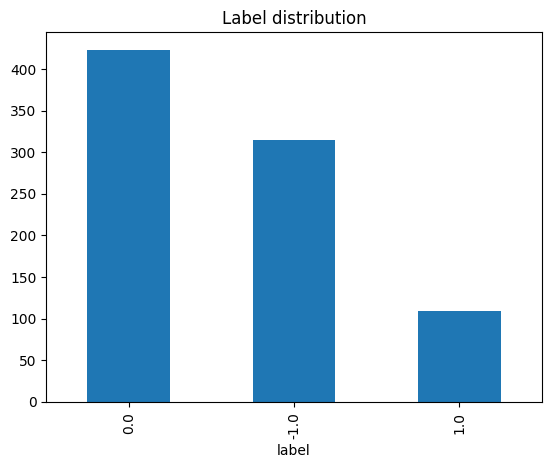

In [74]:
X.label.value_counts().plot(kind = 'bar',
                            title = 'Label distribution',)

### Feature Creation

In [75]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /home/minor/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/minor/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [76]:
import helpers.data_mining_helpers as dmh
X['unigram'] = X['text'].apply(lambda x: dmh.tokenize_text(x))

In [77]:
from sklearn.feature_extraction.text import CountVectorizer
count_vect = CountVectorizer()
X_counts = count_vect.fit_transform(X.text) #learn the vocabulary and return document-term matrix

### show term frequencies

In [78]:
import plotly.express as px

terms = count_vect.get_feature_names_out()
term_frequencies = np.asarray(X_counts.sum(axis=0))[0]
df = pd.DataFrame({"term": terms, "frequency": term_frequencies})
df = df.sort_values(by="frequency", ascending=False).head(300)
fig = px.bar(df, x="term", y="frequency", title="First 300 Term Frequencies")
fig.update_layout(
    xaxis_tickangle=90,
    width=2000,
    height=600,
)
fig.show()

In [79]:
# encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X['label_enc'] = le.fit_transform(X['label'])

# Phase 2

### Remove top freq words and bottom freq words

In [80]:
### Begin Assignment Here
labels = X['label_enc'].unique()
label_dfs = {}
for label in labels:
    label_dfs[label] = X[X['label_enc'] == label].copy()

In [81]:
def create_term_document_df(df):
    count_vect = CountVectorizer()  # Initialize the CountVectorizer
    X_counts = count_vect.fit_transform(df['text'])  # Transform the text data into word counts
    
    # Get the unique words (vocabulary) from the vectorizer
    words = count_vect.get_feature_names_out()
    
    # Create a DataFrame where rows are documents and columns are words
    term_document_df = pd.DataFrame(X_counts.toarray(), columns=words)
    
    return term_document_df

filt_term_document_dfs = {}  # Dictionary to store term-document DataFrames for each category

for label in labels:
    filt_term_document_dfs[label] = create_term_document_df(label_dfs[label])

In [82]:
def filter_top_bottom_words_by_sum(term_document_df, top_percent=0.05, bottom_percent=0.01):
    # Calculate the sum of each word across all documents
    word_sums = term_document_df.sum(axis=0)
    
    # Sort the words by their total sum
    sorted_words = word_sums.sort_values()
    
    # Calculate the number of words to remove
    total_words = len(sorted_words)
    top_n = int(top_percent * total_words)
    bottom_n = int(bottom_percent * total_words)
    
    # Get the words to remove from the top 5% and bottom 1%
    words_to_remove = pd.concat([sorted_words.head(bottom_n), sorted_words.tail(top_n)]).index
    print(f'Bottom {bottom_percent*100}% words: \n{sorted_words.head(bottom_n)}') #Here we print which words correspond to the bottom percentage we filter
    print(f'Top {top_percent*100}% words: \n{sorted_words.tail(top_n)}') #Here we print which words correspond to the top percentage we filter
    # Return the DataFrame without the filtered words
    return term_document_df.drop(columns=words_to_remove)

term_document_dfs = {}

# After exploring the term frequencies, top 2% (almost stop words) and bottom 1% were chosen for removal
for label in labels:
    term_document_dfs[label] = filter_top_bottom_words_by_sum(filt_term_document_dfs[label],
                                                              top_percent=0.03,
                                                              bottom_percent=0.00)

Bottom 0.0% words: 
Series([], dtype: int64)
Top 3.0% words: 
from      19
other     19
down      20
than      20
out       20
        ... 
it       147
is       178
and      193
to       231
the      409
Length: 65, dtype: int64
Bottom 0.0% words: 
Series([], dtype: int64)
Top 3.0% words: 
today     17
me        17
year      18
think     18
good      18
        ... 
is       161
it       165
and      209
to       267
the      396
Length: 82, dtype: int64
Bottom 0.0% words: 
Series([], dtype: int64)
Top 3.0% words: 
up             10
about          10
by             10
now            11
star           11
some           12
technology     12
at             12
their          12
from           13
my             13
good           14
be             14
so             14
have           14
can            14
more           15
are            15
if             15
just           16
they           17
but            18
that           22
you            23
of             27
this           28
with      

In [83]:
from PAMI.extras.convert.DF2DB import DF2DB

for label in labels:
    obj = DF2DB(term_document_dfs[label])
    obj.convert2TransactionalDatabase(f'td_{label}_reddit.csv', '>=', 1)

Database size (total no of transactions) : 315
Number of items : 2127
Minimum Transaction Size : 1
Average Transaction Size : 13.698412698412698
Maximum Transaction Size : 153
Standard Deviation Transaction Size : 15.110634246177211
Variance in Transaction Sizes : 229.05843696289557
Sparsity : 0.9935597495541078


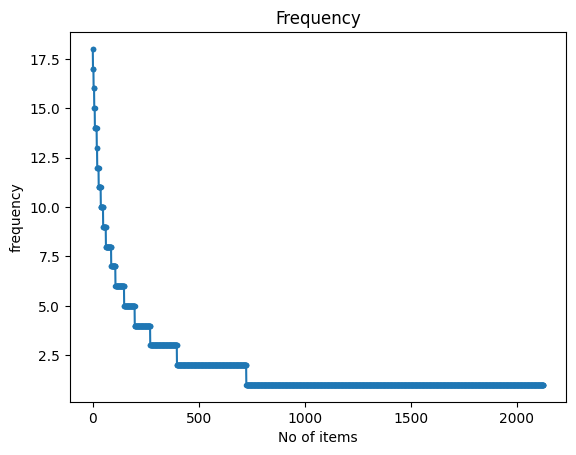

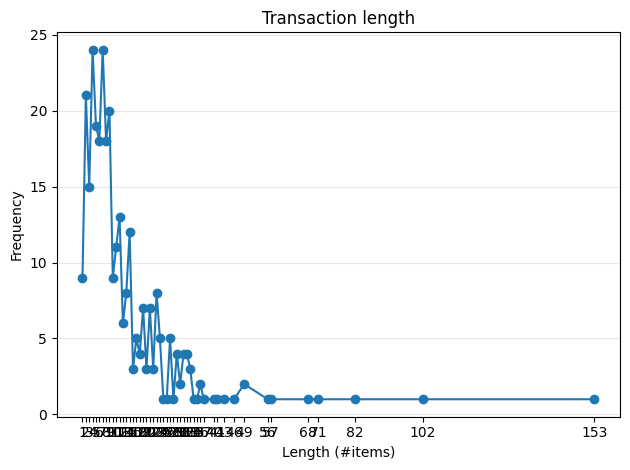

Database size (total no of transactions) : 417
Number of items : 2668
Minimum Transaction Size : 1
Average Transaction Size : 12.369304556354916
Maximum Transaction Size : 216
Standard Deviation Transaction Size : 20.292887030305753
Variance in Transaction Sizes : 412.7911709094263
Sparsity : 0.9953638288769284


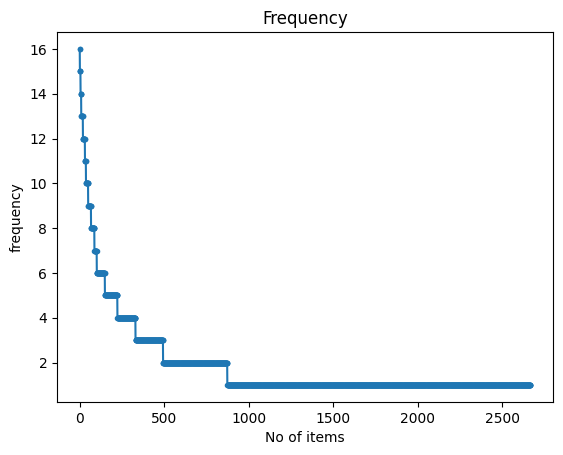

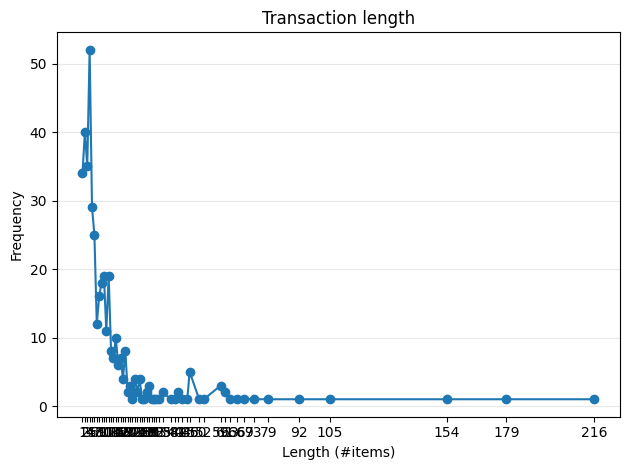

Database size (total no of transactions) : 108
Number of items : 1137
Minimum Transaction Size : 1
Average Transaction Size : 15.712962962962964
Maximum Transaction Size : 95
Standard Deviation Transaction Size : 17.888570179662274
Variance in Transaction Sizes : 322.99160609207337
Sparsity : 0.9861803316068928


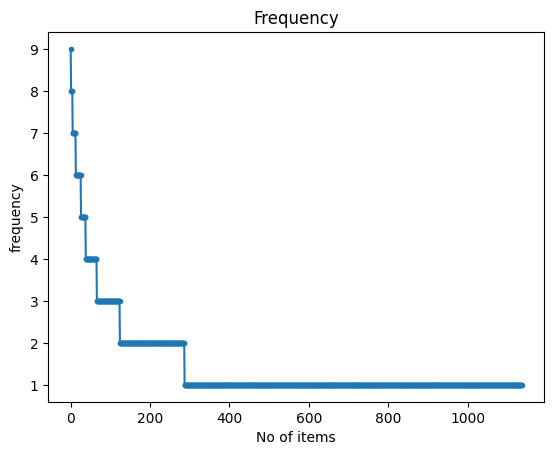

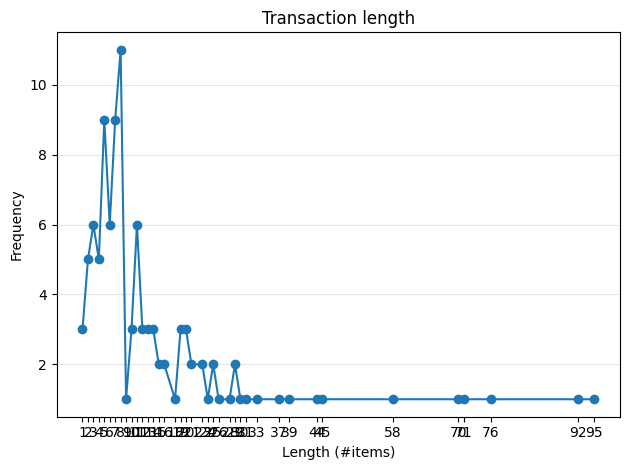

In [84]:
from PAMI.extras.dbStats import TransactionalDatabase as tds
for label in labels:
    obj = tds.TransactionalDatabase(f'td_{label}_reddit.csv')
    obj.run()
    obj.printStats()
    obj.plotGraphs()

In [85]:
from PAMI.frequentPattern.basic import FPGrowth as alg
from PAMI.frequentPattern.topk import FAE as alg
dfs = []
for label in labels:
    # minSup=4
    # obj_fpg = alg.FPGrowth(f'td_{label}_reddit.csv', minSup)
    sep = '\t'
    kCount = 200
    obj = alg.FAE(f'td_{label}_reddit.csv', kCount, sep=sep)
    obj.mine()
    df_fpg = obj.getPatternsAsDataFrame()
    dfs.append(df_fpg)
    print(f'Label {label} - Total No of patterns: ' + str(len(df_fpg))) #print the total number of patterns
    print(f'Label {label} - Runtime: ' + str(obj.getRuntime())) #measure the runtime

 TopK frequent patterns were successfully generated using FAE algorithm.
Label 0 - Total No of patterns: 200
Label 0 - Runtime: 0.006407737731933594
 TopK frequent patterns were successfully generated using FAE algorithm.
Label 1 - Total No of patterns: 200
Label 1 - Runtime: 0.10417985916137695
 TopK frequent patterns were successfully generated using FAE algorithm.
Label 2 - Total No of patterns: 200
Label 2 - Runtime: 0.01676177978515625


In [86]:
# Identify patterns that appear in more than one category
# Count how many times each pattern appears across all dataframes
pattern_counts = {}
for df in dfs:
    for pattern in df['Patterns']:
        if pattern not in pattern_counts:
            pattern_counts[pattern] = 1
        else:
            pattern_counts[pattern] += 1

unique_patterns = {pattern: count for pattern, count in pattern_counts.items() if count == 1}
total_patterns = sum(len(df) for df in dfs)
discarded_patterns_count = total_patterns - len(unique_patterns)

# For each category, filter the patterns to keep only the unique ones
filtered_dfs = []
for df in dfs:
    filtered_df = df[df['Patterns'].isin(unique_patterns)]
    filtered_dfs.append(filtered_df)

final_pattern_df = pd.concat(filtered_dfs, ignore_index=True)
final_pattern_df = final_pattern_df.sort_values(by='Support', ascending=False)
print(final_pattern_df)
# Print the number of discarded patterns
print(f"Number of patterns discarded: {discarded_patterns_count}")

     Patterns  Support
0          up       18
2          by       15
1        some       15
87     always       14
4        fuck       14
..        ...      ...
291      nvda        2
292      rklb        2
293  stimulus        2
294     build        2
295     crash        2

[296 rows x 2 columns]
Number of patterns discarded: 304


In [87]:
X['tokenized_text'] = X['text'].str.split().apply(set)
pattern_matrix = pd.DataFrame(0, index=X.index, columns=final_pattern_df['Patterns'])

# Iterate over each pattern and check if all words in the pattern are present in the tokenized sentence
for pattern in final_pattern_df['Patterns']:
    pattern_words = set(pattern.split())  # Tokenize pattern into words
    pattern_matrix[pattern] = X['tokenized_text'].apply(lambda x: 1 if pattern_words.issubset(x) else 0)
tdm_df = pd.DataFrame(X_counts.toarray(), columns=terms, index=X.index)
augmented_df = pd.concat([tdm_df, pattern_matrix], axis=1)

### BOW

In [88]:
# classification

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

label_mapping = dict(X[['label_enc', 'label']].drop_duplicates().values)
target_names = [str(label_mapping[i]) for i in sorted(label_mapping.keys())]
X_train, X_test, y_train, y_test = train_test_split(tdm_df,
                                                    X['label_enc'],
                                                    test_size=0.2,
                                                    random_state=42)

nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)

y_pred = nb_classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy: 0.5235294117647059
              precision    recall  f1-score   support

        -1.0       0.52      0.69      0.59        67
         0.0       0.55      0.58      0.56        73
         1.0       0.17      0.03      0.06        30

    accuracy                           0.52       170
   macro avg       0.41      0.43      0.40       170
weighted avg       0.47      0.52      0.49       170



### BOW Augmentation

In [89]:
# classification

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

label_mapping = dict(X[['label_enc', 'label']].drop_duplicates().values)
target_names = [str(label_mapping[i]) for i in sorted(label_mapping.keys())]
X_train, X_test, y_train, y_test = train_test_split(augmented_df,
                                                    X['label_enc'],
                                                    test_size=0.2,
                                                    random_state=42)

nb_classifier = MultinomialNB()
nb_classifier.fit(X_train, y_train)

y_pred = nb_classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy: 0.5352941176470588
              precision    recall  f1-score   support

        -1.0       0.53      0.67      0.59        67
         0.0       0.57      0.59      0.58        73
         1.0       0.33      0.10      0.15        30

    accuracy                           0.54       170
   macro avg       0.48      0.45      0.44       170
weighted avg       0.51      0.54      0.51       170



### TFIDF

In [99]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X['text'],
                                                    X['label_enc'],
                                                    test_size=0.2,
                                                    random_state=42)

tfidf_vect = TfidfVectorizer()
X_train_tfidf = tfidf_vect.fit_transform(X_train)
X_test_tfidf = tfidf_vect.transform(X_test)

classifier_tfidf = MultinomialNB()
classifier_tfidf.fit(X_train_tfidf, y_train)

y_pred_tfidf = classifier_tfidf.predict(X_test_tfidf)
print("TF-IDF Accuracy:", accuracy_score(y_test, y_pred_tfidf))
print(classification_report(y_test, y_pred_tfidf, target_names=target_names))

TF-IDF Accuracy: 0.5588235294117647
              precision    recall  f1-score   support

        -1.0       0.70      0.45      0.55        67
         0.0       0.51      0.89      0.65        73
         1.0       0.00      0.00      0.00        30

    accuracy                           0.56       170
   macro avg       0.40      0.45      0.40       170
weighted avg       0.49      0.56      0.49       170



/home/minor/Repos/DM2025Labs/DM2025-Lab1-Exercise/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/home/minor/Repos/DM2025Labs/DM2025-Lab1-Exercise/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/home/minor/Repos/DM2025Labs/DM2025-Lab1-Exercise/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



### TDIDF CNB

In [98]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X['text'],
                                                    X['label_enc'],
                                                    test_size=0.2,
                                                    random_state=42)

tfidf_vect = TfidfVectorizer()
X_train_tfidf = tfidf_vect.fit_transform(X_train)
X_test_tfidf = tfidf_vect.transform(X_test)

classifier_tfidf = ComplementNB()
classifier_tfidf.fit(X_train_tfidf, y_train)

y_pred_tfidf = classifier_tfidf.predict(X_test_tfidf)
print("TF-IDF Accuracy:", accuracy_score(y_test, y_pred_tfidf))
print(classification_report(y_test, y_pred_tfidf, target_names=target_names))

TF-IDF Accuracy: 0.5176470588235295
              precision    recall  f1-score   support

        -1.0       0.54      0.70      0.61        67
         0.0       0.53      0.56      0.54        73
         1.0       0.00      0.00      0.00        30

    accuracy                           0.52       170
   macro avg       0.36      0.42      0.38       170
weighted avg       0.44      0.52      0.47       170



### TDIDF Augmentation

In [100]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from scipy.sparse import hstack

X_train, X_test, y_train, y_test = train_test_split(X['text'],
                                                    X['label_enc'],
                                                    test_size=0.2,
                                                    random_state=42)

tfidf_vect = TfidfVectorizer()
X_train_tfidf = tfidf_vect.fit_transform(X_train)
X_test_tfidf = tfidf_vect.transform(X_test)

train_patterns = pattern_matrix.loc[X_train.index]
test_patterns = pattern_matrix.loc[X_test.index]
X_train_augmented = hstack([X_train_tfidf, train_patterns.values])
X_test_augmented = hstack([X_test_tfidf, test_patterns.values])

classifier_tfidf = MultinomialNB()
classifier_tfidf.fit(X_train_augmented, y_train)

y_pred_augmented = classifier_tfidf.predict(X_test_augmented)
print("TF-IDF Accuracy:", accuracy_score(y_test, y_pred_augmented))
print(classification_report(y_test, y_pred_augmented, target_names=target_names))

TF-IDF Accuracy: 0.5588235294117647
              precision    recall  f1-score   support

        -1.0       0.64      0.52      0.57        67
         0.0       0.52      0.82      0.64        73
         1.0       0.00      0.00      0.00        30

    accuracy                           0.56       170
   macro avg       0.39      0.45      0.40       170
weighted avg       0.47      0.56      0.50       170



/home/minor/Repos/DM2025Labs/DM2025-Lab1-Exercise/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/home/minor/Repos/DM2025Labs/DM2025-Lab1-Exercise/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/home/minor/Repos/DM2025Labs/DM2025-Lab1-Exercise/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



### TFIDF Augmented CNB

In [102]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from scipy.sparse import hstack

X_train, X_test, y_train, y_test = train_test_split(X['text'],
                                                    X['label_enc'],
                                                    test_size=0.2,
                                                    random_state=42)

tfidf_vect = TfidfVectorizer()
X_train_tfidf = tfidf_vect.fit_transform(X_train)
X_test_tfidf = tfidf_vect.transform(X_test)

train_patterns = pattern_matrix.loc[X_train.index]
test_patterns = pattern_matrix.loc[X_test.index]
X_train_augmented = hstack([X_train_tfidf, train_patterns.values])
X_test_augmented = hstack([X_test_tfidf, test_patterns.values])

classifier_tfidf = ComplementNB()
classifier_tfidf.fit(X_train_augmented, y_train)

y_pred_augmented = classifier_tfidf.predict(X_test_augmented)
print("TF-IDF Accuracy:", accuracy_score(y_test, y_pred_augmented))
print(classification_report(y_test, y_pred_augmented, target_names=target_names))

TF-IDF Accuracy: 0.5058823529411764
              precision    recall  f1-score   support

        -1.0       0.54      0.61      0.57        67
         0.0       0.53      0.58      0.55        73
         1.0       0.21      0.10      0.14        30

    accuracy                           0.51       170
   macro avg       0.43      0.43      0.42       170
weighted avg       0.48      0.51      0.49       170



## Conclusion

here is the result table over the methods above:
|Feature Extraction|Classifier|Accuracy|Notes|
|---|---|---|---|
|BOW|MultinomialNB|52.35%|Baseline|
|BOW + Augmentation|MultinomialNB|53.53%|Slight improvement with patterns|
|TF-IDF|MultinomialNB|55.88%|Best performance (No stop-word removal)|
|TF-IDF + Augmentation|MultinomialNB|55.88%|Pattern redundancy observed|
|TF-IDF|ComplementNB|51.76%|Less effective for this specific distribution|
|TF-IDF + Augmentation|ComplementNB|50.58%|Less then TF-IDF with ComplementNB|

### Impact of stop words
Retaining English stop words significantly improved accuracy to 55.88%. I think its because the context of Reddit stock discussions, words like "not" (negation) and "up/down" (direction) are critical sentiment indicators that standard stop-word lists often mistakenly remove.

### Augmentation
Adding frequent patterns provided a 1.2% boost to the BOW model, proving that capturing word associations compensates for the limitations of unigrams. But for the TF-IDF model, the benefits were negligible, suggesting that the TF-IDF weights already captured the relevant contextual importance.

### Imblance
All models struggled with the Positive (1.0) class due to limited support (n=30). The high precision but zero recall in some TF-IDF runs indicates a strong bias toward the majority classes (Neutral and Negative).

### Future improvements
Instead of using generic NLP libraries to remove stop words, a white-list for stock context should be used to protect directional and negation terms.

Also to resampling or over sampling to balence the training distribution.